In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

In [3]:
RAW_PATH = "../project/data/raw"

fund_master = pd.read_csv(f"{RAW_PATH}/01_fund_master.csv")
nav = pd.read_csv(f"{RAW_PATH}/02_nav_history.csv")
aum = pd.read_csv(f"{RAW_PATH}/03_aum_by_fund_house.csv")
sip = pd.read_csv(f"{RAW_PATH}/04_monthly_sip_inflows.csv")
category = pd.read_csv(f"{RAW_PATH}/05_category_inflows.csv")
folio = pd.read_csv(f"{RAW_PATH}/06_industry_folio_count.csv")
performance = pd.read_csv(f"{RAW_PATH}/07_scheme_performance.csv")
transactions = pd.read_csv(f"{RAW_PATH}/08_investor_transactions.csv")
holdings = pd.read_csv(f"{RAW_PATH}/09_portfolio_holdings.csv")
benchmark = pd.read_csv(f"{RAW_PATH}/10_benchmark_indices.csv")

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

aum["date"] = pd.to_datetime(aum["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

holdings["portfolio_date"] = pd.to_datetime(
    holdings["portfolio_date"]
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

In [6]:
RAW_PATH = "../project/data/raw"

fund_master = pd.read_csv(f"{RAW_PATH}/01_fund_master.csv")
nav = pd.read_csv(f"{RAW_PATH}/02_nav_history.csv")
aum = pd.read_csv(f"{RAW_PATH}/03_aum_by_fund_house.csv")
sip = pd.read_csv(f"{RAW_PATH}/04_monthly_sip_inflows.csv")
category = pd.read_csv(f"{RAW_PATH}/05_category_inflows.csv")
folio = pd.read_csv(f"{RAW_PATH}/06_industry_folio_count.csv")
performance = pd.read_csv(f"{RAW_PATH}/07_scheme_performance.csv")
transactions = pd.read_csv(f"{RAW_PATH}/08_investor_transactions.csv")
holdings = pd.read_csv(f"{RAW_PATH}/09_portfolio_holdings.csv")
benchmark = pd.read_csv(f"{RAW_PATH}/10_benchmark_indices.csv")

In [7]:
nav["date"] = pd.to_datetime(nav["date"])

aum["date"] = pd.to_datetime(aum["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

holdings["portfolio_date"] = pd.to_datetime(
    holdings["portfolio_date"]
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [8]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    annotation_text="2024 Market Correction",
    annotation_position="top right"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    template="plotly_white",
    height=700
)

fig.show()

## Insight 1

The daily NAV trend shows overall growth across most mutual fund schemes. The highlighted 2023 period represents a strong market uptrend, while 2024 indicates periods of market correction with comparatively slower NAV growth.

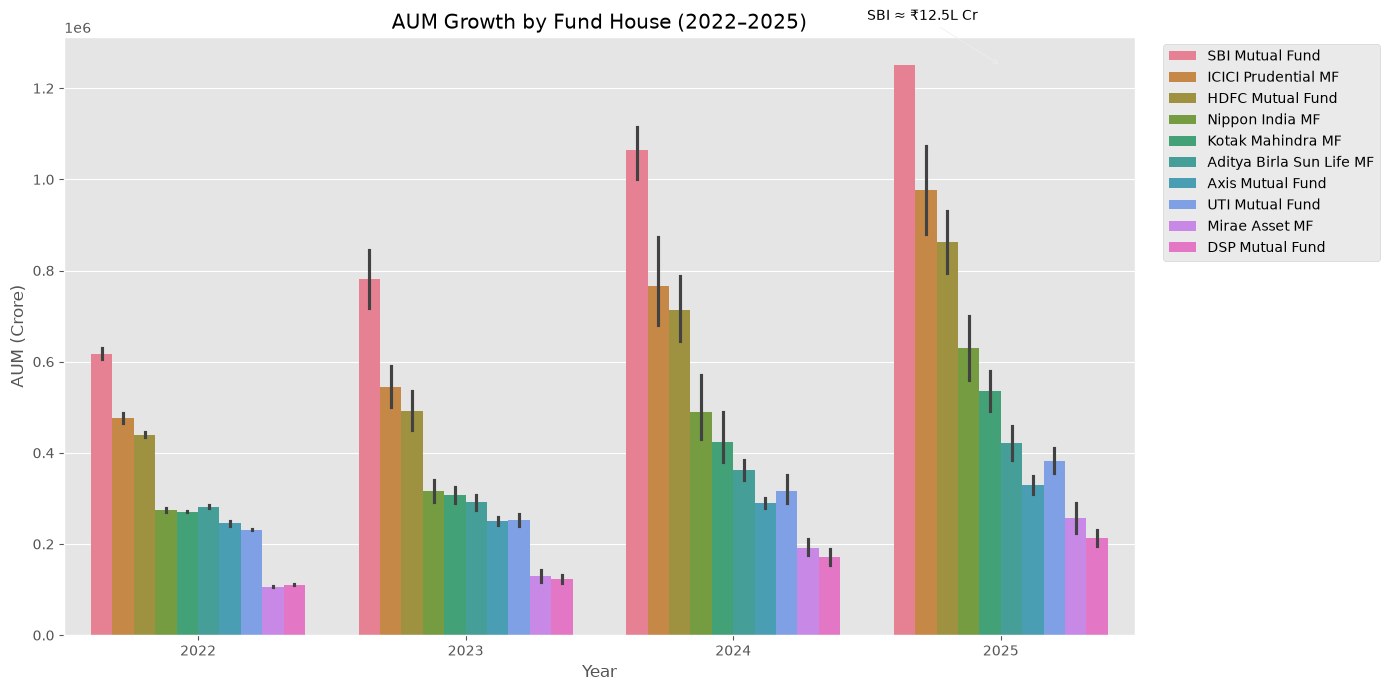

In [9]:
# AUM Growth by Fund House

aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=0)

# Highlight SBI dominance
plt.annotate(
    "SBI ≈ ₹12.5L Cr",
    xy=(3, 1250000),
    xytext=(2.5, 1350000),
    arrowprops=dict(arrowstyle="->")
)

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()

plt.show()

## Insight 2

SBI Mutual Fund maintained the highest Assets Under Management (AUM) among all fund houses, reaching approximately ₹12.5 lakh crore by 2025. Other major fund houses also showed steady year-over-year growth.

In [10]:
plt.savefig("../reports/aum_growth.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [14]:
# SIP Inflow Time-Series

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr (Dec 2025)",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white",
    height=600
)

fig.show()

## Insight 3

Monthly SIP inflows showed consistent growth from 2022 to 2025, reaching an all-time high of ₹31,002 crore in December 2025. This indicates increasing retail investor participation through systematic investment plans.

In [15]:
fig.write_image("sip_inflow_trend.png")

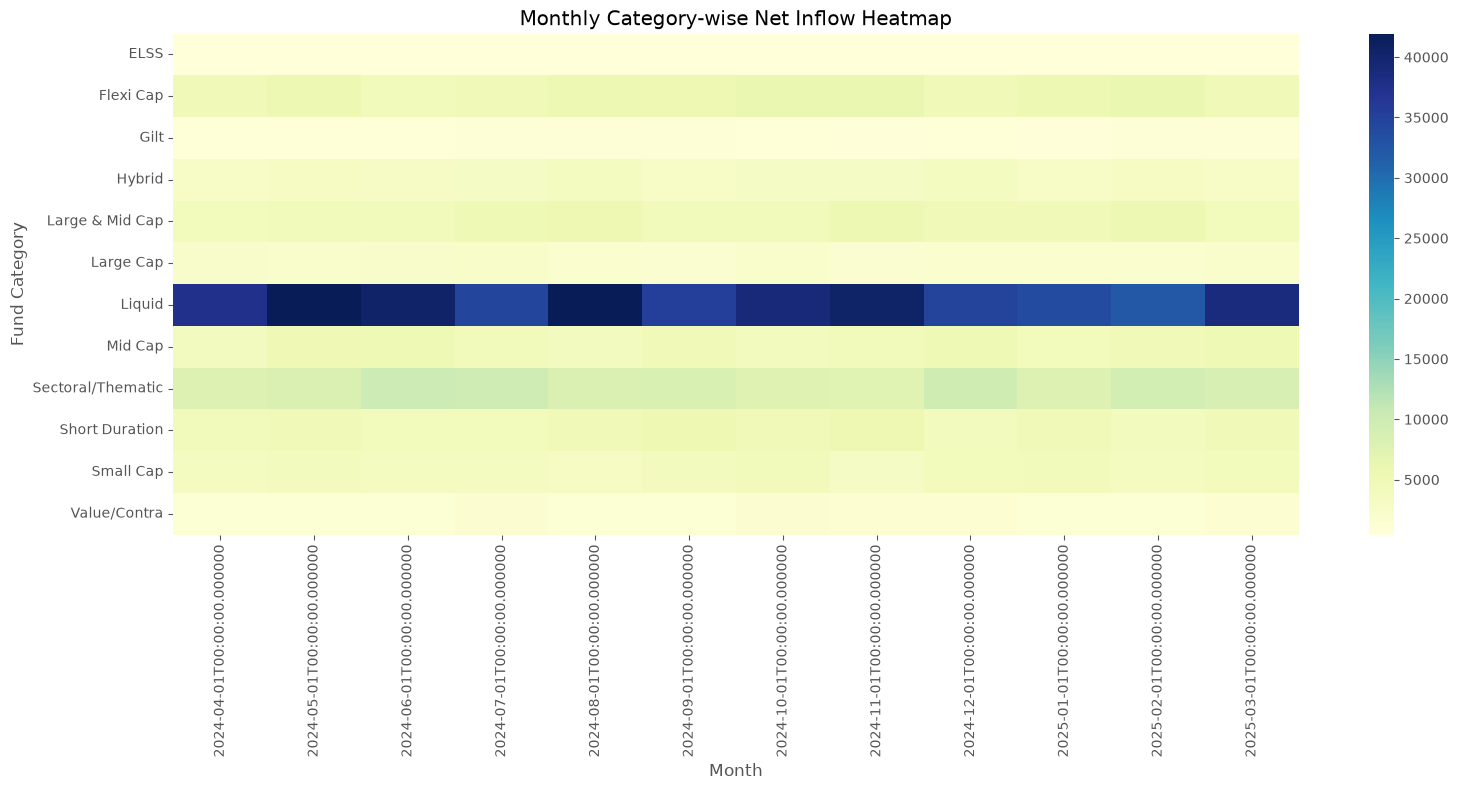

In [16]:
# Category Inflow Heatmap

category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False
)

plt.title("Monthly Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.show()

## Insight 4

Category inflow analysis shows changing investor preferences across different mutual fund categories over time, with higher intensity areas representing stronger net inflows.


In [17]:
plt.savefig(
    "category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [18]:
# Age Group Distribution

age_count = transactions["age_group"].value_counts()

fig = px.pie(
    values=age_count.values,
    names=age_count.index,
    title="Investor Age Group Distribution"
)

fig.show()

## Insight 5

Investor age distribution shows the participation pattern across different age groups, helping identify the most active investor segments.

In [19]:
fig.write_image("age_group_distribution.png")

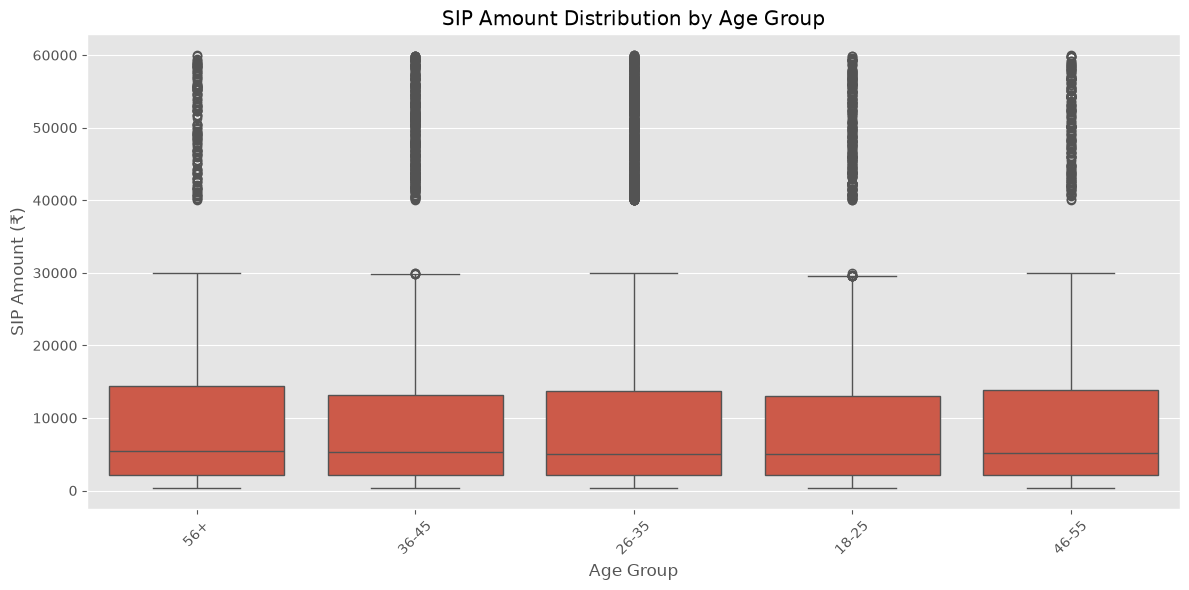

In [20]:
# SIP Amount Distribution by Age Group

sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [21]:
plt.savefig(
    "sip_amount_age_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [22]:
gender_count = transactions["gender"].value_counts()

fig = px.pie(
    values=gender_count.values,
    names=gender_count.index,
    title="Investor Gender Split"
)

fig.show()

## Insight 6

Gender distribution analysis shows investor participation split between different gender groups within the mutual fund dataset.

In [23]:
fig.write_image("gender_split.png")

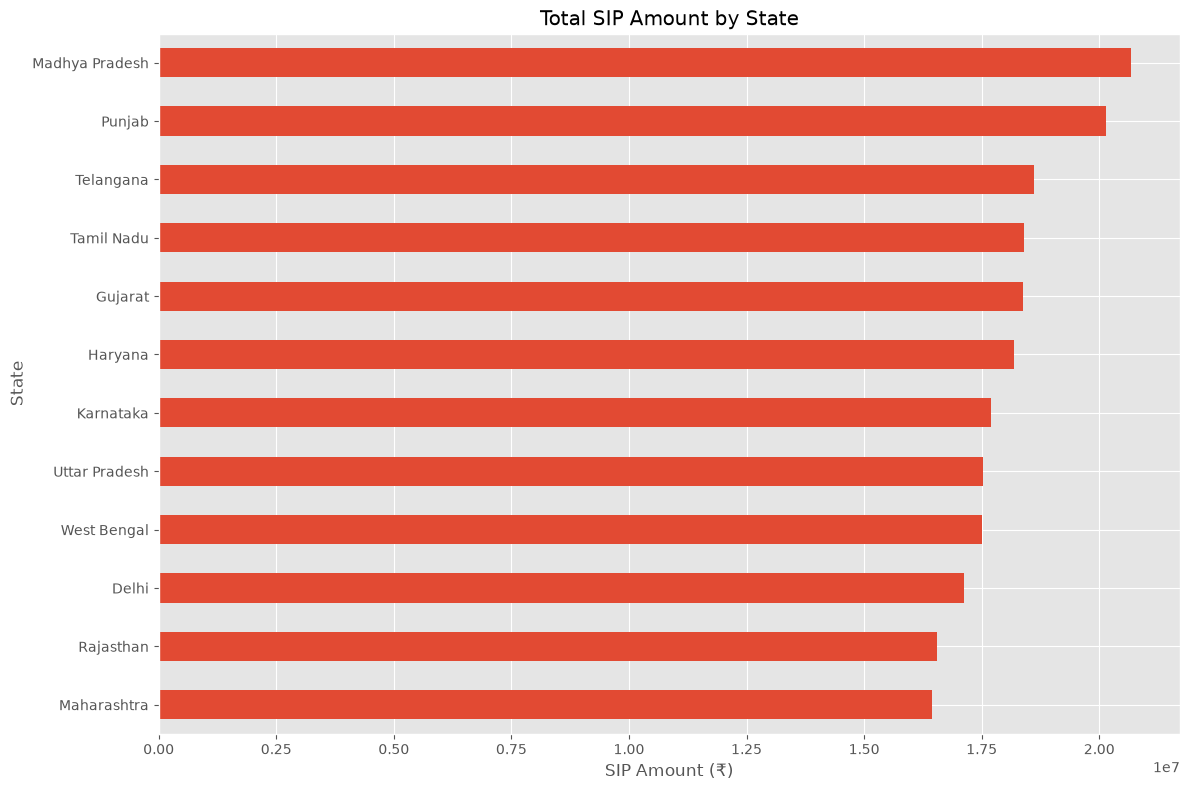

In [24]:
# SIP Amount by State

state_sip = (
    transactions[
        transactions["transaction_type"] == "SIP"
    ]
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(12,8))

state_sip.plot(
    kind="barh"
)

plt.title("Total SIP Amount by State")
plt.xlabel("SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.show()

## Insight 7

Geographic SIP analysis highlights state-wise investment contribution, showing regions with stronger mutual fund participation.

In [25]:
plt.savefig(
    "state_sip_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [26]:
# City Tier Distribution

city_tier = transactions["city_tier"].value_counts()

fig = px.pie(
    values=city_tier.values,
    names=city_tier.index,
    title="T30 vs B30 Investor Distribution"
)

fig.show()

## Insight 8

City tier distribution shows investor participation across T30 and B30 regions, reflecting mutual fund penetration beyond major cities.

In [27]:
# Folio Count Growth

folio["month"] = pd.to_datetime(folio["month"])

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Mutual Fund Folio Count Growth (2022–2025)"
)

# Starting milestone
fig.add_annotation(
    x="2022-01-01",
    y=13.26,
    text="13.26 Cr (Jan 2022)",
    showarrow=True,
    arrowhead=2
)

# Ending milestone
fig.add_annotation(
    x="2025-12-01",
    y=26.12,
    text="26.12 Cr (Dec 2025)",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)",
    template="plotly_white"
)

fig.show()

## Insight 9

Mutual fund folio count increased significantly from 13.26 crore in January 2022 to 26.12 crore in December 2025, showing strong growth in investor participation.

In [28]:
fig.write_image(
    "folio_count_growth.png"
)

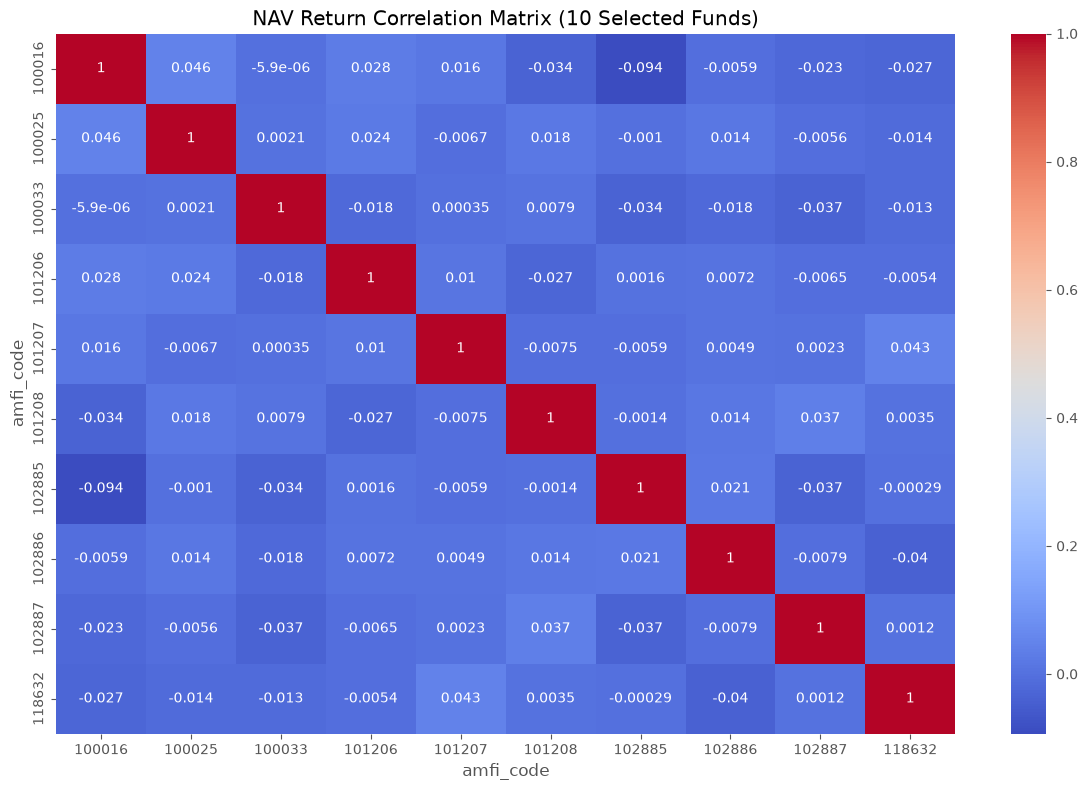

In [29]:
# NAV Return Correlation Matrix

nav_pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

selected_funds = nav_pivot.iloc[:, :10]

returns = selected_funds.pct_change()

correlation = returns.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "NAV Return Correlation Matrix (10 Selected Funds)"
)

plt.tight_layout()

plt.show()

In [30]:
plt.savefig(
    "nav_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Insight 10

NAV return correlation analysis shows the relationship between selected funds and helps identify similar performance movement patterns.

In [31]:
# Sector Allocation Donut

sector_data = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
)

fig = px.pie(
    sector_data,
    names="sector",
    values="weight_pct",
    hole=0.5,
    title="Sector Allocation Across Equity Funds"
)

fig.show()

In [32]:
fig.write_image(
    "sector_allocation_donut.png"
)

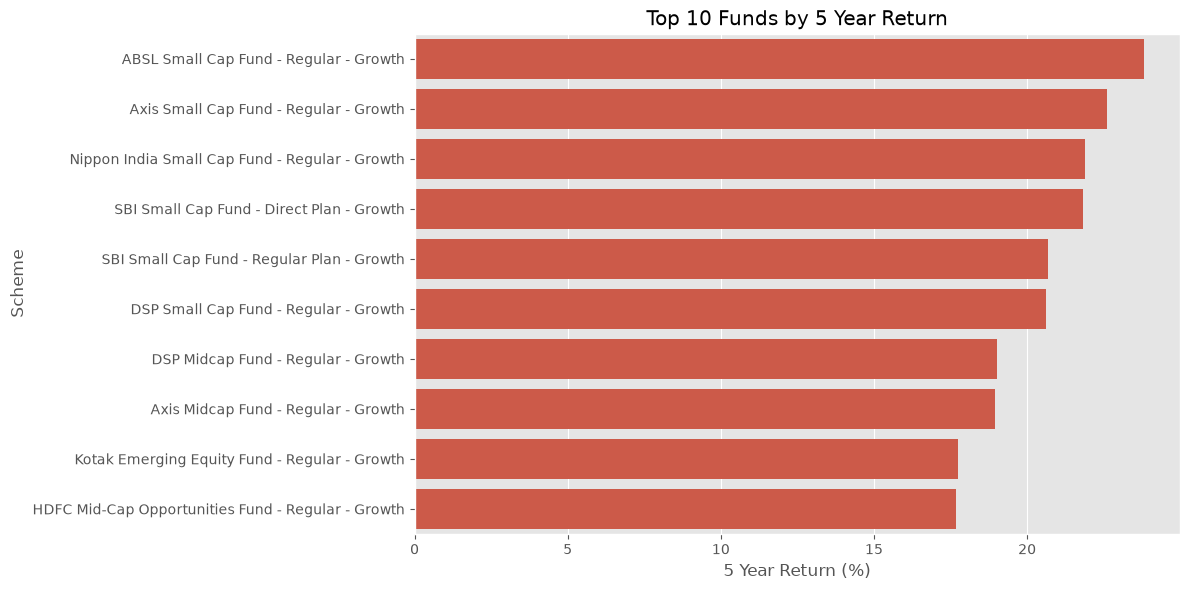

In [33]:
top_returns = performance.sort_values(
    "return_5yr_pct",
    ascending=False
).head(10)


plt.figure(figsize=(12,6))

sns.barplot(
    data=top_returns,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title(
    "Top 10 Funds by 5 Year Return"
)

plt.xlabel("5 Year Return (%)")
plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

In [34]:
plt.savefig(
    "top_10_returns.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

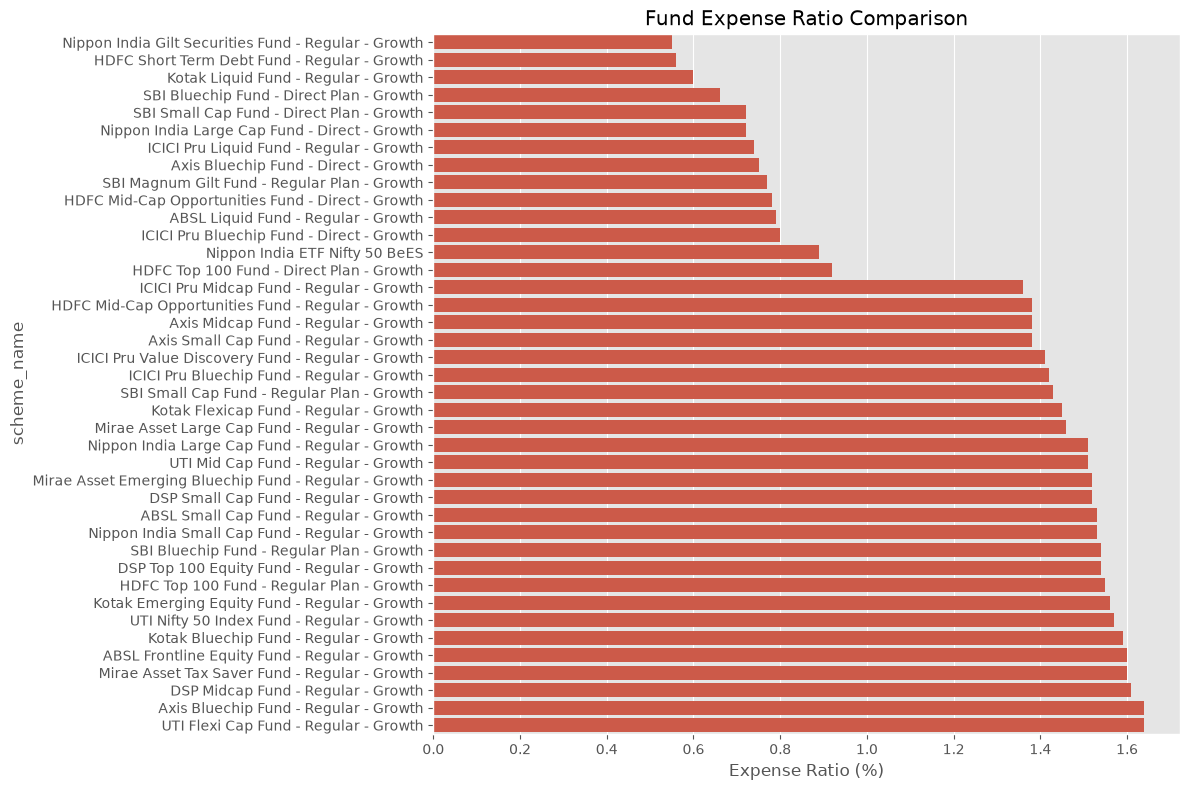

In [35]:
expense = performance.sort_values(
    "expense_ratio_pct"
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=expense,
    x="expense_ratio_pct",
    y="scheme_name"
)

plt.title(
    "Fund Expense Ratio Comparison"
)

plt.xlabel("Expense Ratio (%)")

plt.tight_layout()

plt.show()

In [36]:
fig = px.line(
    benchmark,
    x="date",
    y="close_value",
    color="index_name",
    title="Benchmark Index Trend"
)

fig.show()

In [38]:
fig.write_image(
    "benchmark_index_trend.png"
)

# Key EDA Findings Summary

1. NAV values showed overall growth from 2022–2026.
2. 2023 showed strong bullish movement across schemes.
3. 2024 reflected market correction phases.
4. SBI maintained highest AUM dominance.
5. SIP inflows reached record levels in Dec 2025.
6. Equity categories attracted strong inflows.
7. Younger investors showed significant SIP participation.
8. B30 cities contributed to expanding mutual fund adoption.
9. Folio count nearly doubled between 2022 and 2025.
10. Fund return correlation showed similar movement patterns among selected schemes.